# Comparison of Hydrodynamics.jl and WEC-Sim
This notebook demonstrates solving the motion of a hydrodynamic system, calculating power, and evaluating the gradient of the system power with respect to PTO damping.

1. Define or ingest hydrodynamic coefficients
2. Define numerical simulation parameters and wave conditions
3. Define body mass properties, initial conditions, and PTO damping
4. Solve the system and calculate power
5. Gradient of power with respect to PTO damping

In [1]:
# First import all necessary julia packages:
using Unitful
using DimensionfulAngles: radᵃ as rad, θ₀, 𝐀, Dispersion
using LinearAlgebra
using Plots
import Random
import NetCDF
import ForwardDiff as FD
import WaveSpectra

include("..\\src\\Hydrodynamics.jl")

Main.Hydrodynamics

First define a helper function that reads CSV data containing WEC-Sim results

In [2]:
# Run WEC-Sim simulations outside of this notebook
function read_csv_numeric(filename::String; delim::Char = ',')
    data = Float64[]
    rows = 0
    open(filename, "r") do io
        for line in eachline(io)
            values = split(chomp(line), delim)
            append!(data, parse.(Float64, values))
            rows += 1
        end
    end
    ncols = length(data) ÷ rows
    return reshape(data, ncols, rows)'[:,:]  # transpose to get rows as rows
end

read_csv_numeric (generic function with 1 method)

First define the degrees of freedom for the system and the hydrodynamic data.

In [3]:
# DOFs of the system
dof = 1:2:5
n_dof = length(dof)
dof_names = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"][dof]

# Wave conditions
Hₛ₀ = 1.0
Tₑ = 6.0

# Time-domain set-up
t0 = 0.0
tr = Tₑ * 1.0
tf = Tₑ * 10.0
dt = 1.0e-2
ts = collect(t0:dt:tf)
nt = length(ts)
i_ramp = Int64(tr / dt + 1)

# Flag to switch between regular and irregular waves
regularWave = false

false

In [4]:
# Hydrodynamics
bem_file = "data//rm3.nc"

A = NetCDF.ncread(bem_file, "added_mass")[dof, dof, :] # Dimensions: influenced_dof radiating_dof omega
B = NetCDF.ncread(bem_file, "radiation_damping")[dof, dof, :] # Dimensions: influenced_dof radiating_dof omega
Kₕₛ = NetCDF.ncread(bem_file, "hydrostatic_stiffness")[dof, dof]' # Dimensions: radiating_dof influenced_dof --> influenced_dof radiating_dof
fₑₓ = NetCDF.ncread(bem_file, "excitation_force")[dof, :, :, :] # Dimensions: influenced_dof wave_dir omega complex
fₑₓ[:,:,:,2] = -1 .* fₑₓ[:,:,:,2] # Convert Capytaine's convention to one in which the wave propagates in +X

ω = NetCDF.ncread(bem_file, "omega")
dω = ω[2] - ω[1]
nω = length(ω)

f = ω/(2*pi)
df = dω/(2*pi)

# Hydrostatics parameters - these should also come from BEM
cg = [0., 0., -0.72]
volume = 725.8330
cb = [0.0, 0.0, -1.2927]

3-element Vector{Float64}:
  0.0
  0.0
 -1.2927

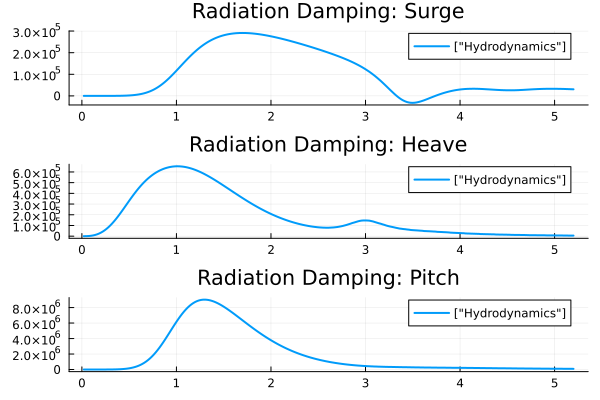

In [5]:
p1 = Plots.plot(ω, B[1,1,:], label = ["Hydrodynamics"], title = "Radiation Damping: Surge", lw = 2)
p2 = Plots.plot(ω, B[2,2,:], label = ["Hydrodynamics"], title = "Radiation Damping: Heave", lw = 2)
p3 = Plots.plot(ω, B[3,3,:], label = ["Hydrodynamics"], title = "Radiation Damping: Pitch", lw = 2)
Plots.plot(p1, p2, p3, layout=(3,1))

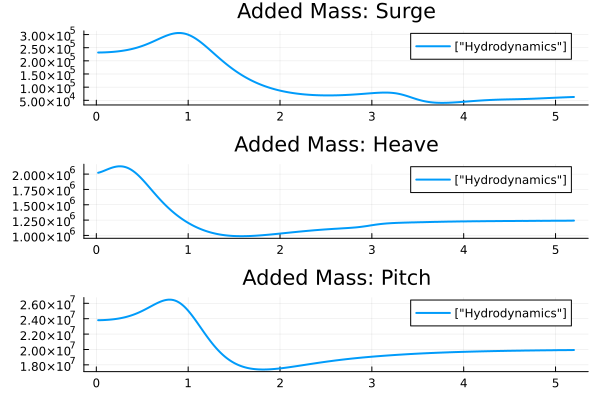

In [6]:
p1 = Plots.plot(ω, A[1,1,:], label = ["Hydrodynamics"], title = "Added Mass: Surge", lw = 2)
p2 = Plots.plot(ω, A[2,2,:], label = ["Hydrodynamics"], title = "Added Mass: Heave", lw = 2)
p3 = Plots.plot(ω, A[3,3,:], label = ["Hydrodynamics"], title = "Added Mass: Pitch", lw = 2)
Plots.plot(p1, p2, p3, layout=(3,1))

### Convolution integral and state space forms of the radiation damping
The radiation damping can also be represented by a convolution integral of the radiation impulse response function and the velocity history. This integral is commonly represented in a state space form to decrease computational expense of the simulation.

Note that this form uses the infinite frequency added mass, which requires recalculating the total mass matrix of the system and its inverse.

In [7]:
# Convolution integral calculation
Kᵣ, tᵣ = Hydrodynamics.Bemio.radiation_irf(B, ω, w_max = 5.0, t=collect(0:dt:30)')
Ainf = A[:,:,end]
Ainf_alt = Hydrodynamics.Bemio.alternate_Ainf(Kᵣ, A, ω, tᵣ)
cic = (Kᵣ, tᵣ)

# State space formation
Aᵣ, Bᵣ, Cᵣ, Dᵣ, Kₛₛ, R²ₛₛ, orderₛₛ = Hydrodynamics.Bemio.radiation_state_space(Kᵣ, tᵣ, 8, 0.95)
nₛₛ = sum(orderₛₛ)
s₀ = zeros(nₛₛ)
ss = (Aᵣ, Bᵣ, Cᵣ, Dᵣ, nₛₛ)

dof: 1 1; order: 4
dof: 1 2; order: 4
dof: 1 3; order: 4
dof: 2 1; order: 6
dof: 2 2; order: 2
dof: 2 3; order: 4
dof: 3 1; order: 2
dof: 3 2; order: 6
dof: 3 3; order: 2


([-1.1025040990653165 -1.8161567916342234 … 0.0 0.0; 1.8161567916342327 -0.0014787328125852764 … 0.0 0.0; … ; 0.0 0.0 … -5.775304791415421e-5 -1.3055955846502856; 0.0 0.0 … 1.3055955846503238 -0.800396838152411], [-62.434742658489235 0.0 0.0; 2.236360714396164 0.0 0.0; … ; 0.0 0.0 -2.391249172754237; 0.0 0.0 280.03481973211734], [-6243.474265848874 -223.63607143961923 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 239.12491727534385 28003.481973211656], [1490.5894513547812 7.614670184837074e-10 9225.537749499157; 8.184417242141109e-13 2613.4589413400245 9.456545097876747e-10; 5659.643218210067 6.863943208706765e-10 26479.353100116103], 34)

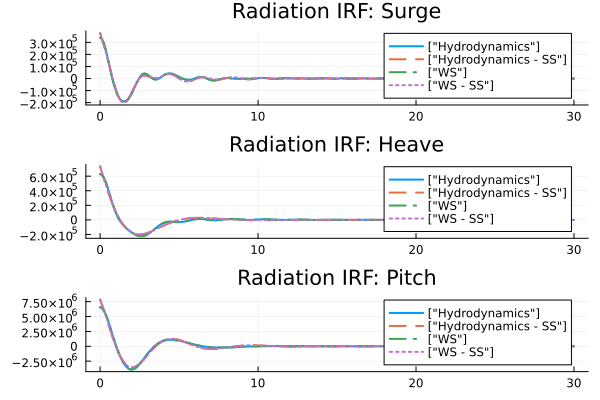

In [8]:
# WEC-Sim IRFs
ws_irf = permutedims(reshape(read_csv_numeric("data\\ws_irf.csv"), 3001, 3, 3), [2, 3, 1])
ws_ss_irf = permutedims(reshape(read_csv_numeric("data\\ws_ss_irf.csv"), 3001, 3, 3), [2, 3, 1])
ws_irf_t = collect(0:0.01:30)

# Compare IRFs to WEC-Sim 
# Visualize response
i = 1
p1 = Plots.plot(tᵣ[1,1,:], Kᵣ[i,i,:], label = ["Hydrodynamics"], title = "Radiation IRF: Surge", lw = 2)
p1 = Plots.plot!(tᵣ[1,1,:], Kₛₛ[i,i,:], label = ["Hydrodynamics - SS"], lw = 2, ls=:dash)
p1 = Plots.plot!(ws_irf_t, ws_irf[i,i,:], label = ["WS"], lw = 2, ls=:dashdot)
p1 = Plots.plot!(ws_irf_t, ws_ss_irf[i,i,:], label = ["WS - SS"], lw = 2, ls=:dot)

i = 2
p2 = Plots.plot(tᵣ[1,1,:], Kᵣ[i,i,:], label = ["Hydrodynamics"], title = "Radiation IRF: Heave", lw = 2)
p2 = Plots.plot!(tᵣ[1,1,:], Kₛₛ[i,i,:], label = ["Hydrodynamics - SS"], lw = 2, ls=:dash)
p2 = Plots.plot!(ws_irf_t, ws_irf[i,i,:], label = ["WS"], lw = 2, ls=:dashdot)
p2 = Plots.plot!(ws_irf_t, ws_ss_irf[i,i,:], label = ["WS - SS"], lw = 2, ls=:dot)

i = 3
p3 = Plots.plot(tᵣ[1,1,:], Kᵣ[i,i,:], label = ["Hydrodynamics"], title = "Radiation IRF: Pitch", lw = 2)
p3 = Plots.plot!(tᵣ[1,1,:], Kₛₛ[i,i,:], label = ["Hydrodynamics - SS"], lw = 2, ls=:dash)
p3 = Plots.plot!(ws_irf_t, ws_irf[i,i,:], label = ["WS"], lw = 2, ls=:dashdot)
p3 = Plots.plot!(ws_irf_t, ws_ss_irf[i,i,:], label = ["WS - SS"], lw = 2, ls=:dot)

Plots.plot(p1, p2, p3, layout=(3,1))

### Wave conditions and numerical set-up
Define relevant wave using WaveSpectra representations (including significant wave height, energy period, spectra, frequency dimension, etc) and time marching parameters (start, ramp, end times; time step)

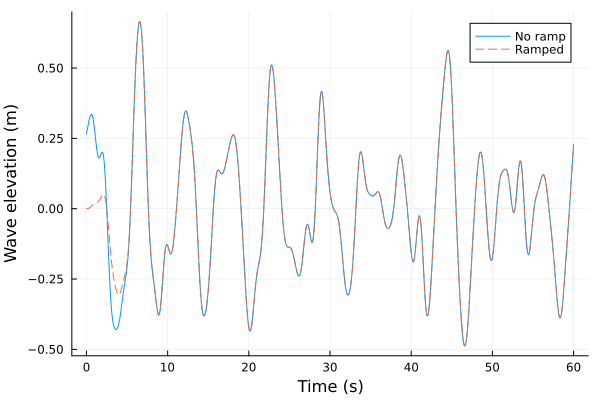

In [9]:
S = WaveSpectra.ParametricSpectra.spectrum_pierson_moskowitz(f*u"s^-1", Hₛ₀*u"m", Tₑ*u"s")
S = Unitful.ustrip.(S)
ϕ = rand(Random.Xoshiro(0), Float64, size(S)) * 2 * pi

# Convert to a regular wave
if regularWave
    ω_bem_index = argmin(abs.(ω .- 2*pi/Tₑ))
    S.data[:] .= 0
    S[ω_bem_index] = (Hₛ₀/2)^2 / (2*df)
    ϕ = ϕ .* 0.0
    A[:, :, [1:ω_bem_index-1; ω_bem_index+1:nω]] .= 0
    B[:, :, [1:ω_bem_index-1; ω_bem_index+1:nω]] .= 0
    fₑₓ[:, :, [1:ω_bem_index-1; ω_bem_index+1:nω], :] .= 0

    ω = ω[ω_bem_index-1:ω_bem_index+1]
    S = S[ω_bem_index-1:ω_bem_index+1]
    ϕ = ϕ[ω_bem_index-1:ω_bem_index+1]
    A = A[:, :, ω_bem_index-1:ω_bem_index+1]
    B = B[:, :, ω_bem_index-1:ω_bem_index+1]
    fₑₓ = fₑₓ[:, :, ω_bem_index-1:ω_bem_index+1, :]

end

# Track the spectral peak
maxS_index = argmax(S)

# Calculate and visualize the wave elevation
ramp_timeseries = zeros(length(ts))
for i = 1:length(ts)
    ramp_timeseries[i] = Hydrodynamics.ramp_function(t0, tr, ts[i])
end

elevation = sum(sqrt.(2*S*df) .* cos.(ω.*ts' .+ ϕ), dims=1)'
ramped_elevation = elevation .* ramp_timeseries
Plots.plot(ts, elevation, xlabel = "Time (s)", ylabel = "Wave elevation (m)", label = "No ramp")
Plots.plot!(ts, ramped_elevation, xlabel = "Time (s)", ylabel = "Wave elevation (m)", label = "Ramped", ls=:dash)

### Define body properties
The required body properties include center of gravity and center of buoyancy, mass, moments and products of inertia, displaced volume, and any initial displacements of the bodies.

PTO damping is lumped with radiation damping when the system of equations is solved, but it is defined as a separate input parameter so that it is a distinct input to power production and can be optimized accordingly.

In [10]:
# Body properties
m = 725833
Ixx = [20907301, 21306090.66, 37085481.11]
Ixy = [0, 0, 0]
I = diagm(Ixx)
I[1, 2:3] = I[2:3, 1] = Ixy[1:2]
I[2, 3] = I[3, 2] = Ixy[3]
body_mass = [diagm(repeat([m], 3)) repeat([0], 3, 3); repeat([0], 3, 3) I]

# Coefficients for the form: ẍ + c * ẋ + k * x = 0
mass = body_mass[dof, dof] .+ A[:,: , maxS_index]
inv_mass = inv(mass)

# Infinite frequency mass calculations
# mass_inf = body_mass[dof,dof] .+ Ainf
mass_inf = body_mass[dof,dof] .+ Ainf_alt
inv_mass_inf = inv(mass_inf)

g = zeros(6)
g[3] = -NetCDF.ncread(bem_file, "g")[1]
force_gravity = diag(body_mass) .* g
rho = NetCDF.ncread(bem_file, "rho")[1]
force_buoyancy = - rho * g * volume
CGCB = cb - cg
force_buoyancy[4:6] = cross(CGCB, force_buoyancy[1:3])
force_hydrostatic = force_gravity[dof] + force_buoyancy[dof]

# Initial conditions
x₀ = zeros(size(dof))
dx₀ = zeros(size(dof))
u₀ = [x₀; dx₀]
u₀_ss = [x₀; dx₀; s₀]

# PTO parameters
kₚₜₒ = diagm(zeros(size(dof)))
cₚₜₒ = diagm(zeros(size(dof)))
pto = (x₀, kₚₜₒ, cₚₜₒ)

# Mooring parameters
kₘ = diagm(zeros(size(dof)))
cₘ = diagm(zeros(size(dof)))
mooring = (x₀, kₘ, cₘ)

([0.0, 0.0, 0.0], [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0])

### System parameter formatting and energy functions 
All parameters for the system are stored in the tuple `p` to be input to the relevation hydrodynamic and power calculation functions.

In [11]:
# Unitful and unitless parameter groups
wave = (ω, ϕ, S, df, t0, tr)
hydro =  (Kₕₛ, B[:,:,maxS_index], fₑₓ, force_hydrostatic, wave) # optionally cic or ss tuples on the end
p_point = (inv_mass, hydro, pto, mooring)

hydro_cic = (Kₕₛ, B[:,:,maxS_index].*0.0, fₑₓ, force_hydrostatic, wave, cic)
p_cic = (inv_mass_inf, hydro_cic, pto, mooring)

hydro_ss = (Kₕₛ, B[:,:,maxS_index].*0.0, fₑₓ, force_hydrostatic, wave, ss)
p_ss = (inv_mass_inf, hydro_ss, pto, mooring)

([1.2063865545448016e-6 -5.301933571327653e-21 -9.983601661369655e-9; 4.472794145736849e-22 5.066581957062828e-7 8.128504967819863e-23; -2.0633223320446002e-8 1.6257278869550731e-22 2.4299342833235695e-8], ([0.0 0.0 0.0; 0.0 2.8009728217349667e6 1.1152678780490533e-9; 0.0 1.1152678780490533e-9 7.206113481356028e7], [0.0 -0.0 0.0; -0.0 0.0 -0.0; 0.0 -0.0 0.0], [2.0311041737386404e-8; 2.8001482923547793e6; 2.1285016593708406e-7;;; 5.179072573469057e-6; 2.797665062134365e6; 5.425501727529536e-5;;; 0.00013186801719200503; 2.793499390076672e6; 0.0013805005377349744;;; … ;;; 2961.423416463907; 609.279939604098; -116.27806247850049;;; -2730.4245875278366; 568.9036671246315; -1950.879191356708;;; -8358.99855510351; 555.4191684153839; -3663.187884503496;;;; 375.2554181510859; 0.3394843812692425; 3932.7180457749105;;; 1500.7369278289316; 5.411167118690884; 15721.822910428762;;; 3375.588449860431; 27.22483262514926; 35340.19594658676;;; … ;;; 10259.617906112284; 407.8930066804164; 7589.0464757132

## Solve and visualize the system response
Solve the system for the given inputs and visualize its response.

In [12]:
# Solve the hydrodynamic system
solution_point = Hydrodynamics.hydrodynamic_solver(u₀, ts, p_point, method=:point)
solution_cic = Hydrodynamics.hydrodynamic_solver(u₀, ts, p_cic, method=:cic)
solution_ss = Hydrodynamics.hydrodynamic_solver(u₀_ss, ts, p_ss, method=:ss)

retcode: Success
Interpolation: 1st order linear
t: 6001-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  ⋮
 59.92
 59.93
 59.94
 59.95
 59.96
 59.97
 59.98
 59.99
 60.0
u: 6001-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [9.989884187649258e-12, 1.1514103393161211e-11, 1.4612703812204401e-12, 3.989885577102225e-9, 4.606227063584835e-9, 5.836725696235813e-10, -6.227095318891147e-10, 2.0079431375123882e-11, 2.171800661045327e-10, 1.8725817187820098e-10  …  -2.1594483218452868e-11, 1.3175608525610397e-9, -4.493734779380669e-16, 4.1291216906981615e-17, -3.329419131533199e-17, -1.2710585431476632e-16, -1.5363159322043245e-16, 1.2990510623009841e-16, -4.5623442734966156e-12, 4.085403389657897e-10]
 [1.5886400573450308e-10, 1.843144643854421e-10, 2.3245964122931337e-11, 3.167506469632213e-8, 3.687128330716022e-8, 4.635689915227082e-9, -9.886462479272988

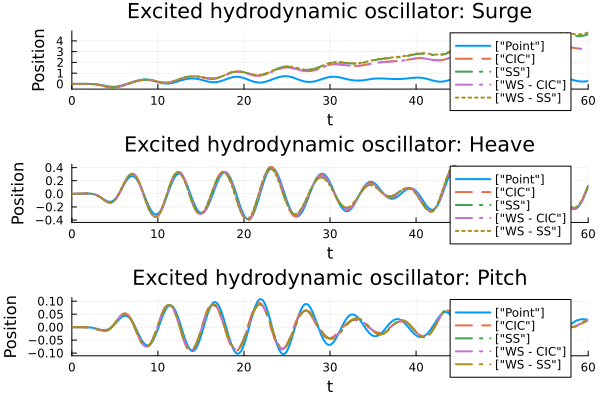

In [13]:
# WEC-Sim solutions
if regularWave
    solution_ws_cic = read_csv_numeric("data\\ws_output_reg_cic.csv")
    solution_ws_ss = read_csv_numeric("data\\ws_output_reg_ss.csv")
else
    solution_ws_cic = read_csv_numeric("data\\ws_output_irr_cic.csv")
    solution_ws_ss = read_csv_numeric("data\\ws_output_irr_ss.csv")
end

# Visualize response
p1 = Plots.plot(solution_point, idxs = [1], label = ["Point"], legend = :topright, title = "Excited hydrodynamic oscillator: Surge", xaxis="Time", yaxis = "Position", lw = 2,)
p1 = Plots.plot!(solution_cic, idxs = [1], label = ["CIC"], lw = 2, ls=:dash)
p1 = Plots.plot!(solution_ss, idxs = [1], label = ["SS"], lw = 2, ls=:dashdot)
p1 = Plots.plot!(solution_ws_cic[:,1], solution_ws_cic[:,2] .- cg[1], label = ["WS - CIC"], lw = 2, ls=:dashdotdot)
p1 = Plots.plot!(solution_ws_ss[:,1], solution_ws_ss[:,2] .- cg[1], label = ["WS - SS"], lw = 2, ls=:dot)

p2 = Plots.plot(solution_point, idxs = [2], label = ["Point"], legend = :topright, title = "Excited hydrodynamic oscillator: Heave", xaxis="Time", yaxis = "Position", lw = 2,)
p2 = Plots.plot!(solution_cic, idxs = [2], label = ["CIC"], lw = 2, ls=:dash)
p2 = Plots.plot!(solution_ss, idxs = [2], label = ["SS"], lw = 2, ls=:dashdot)
p2 = Plots.plot!(solution_ws_cic[:,1], solution_ws_cic[:,3] .- cg[3], label = ["WS - CIC"], lw = 2, ls=:dashdotdot)
p2 = Plots.plot!(solution_ws_ss[:,1], solution_ws_ss[:,3] .- cg[3], label = ["WS - SS"], lw = 2, ls=:dot)

p3 = Plots.plot(solution_point, idxs = [3], label = ["Point"], legend = :topright, title = "Excited hydrodynamic oscillator: Pitch", xaxis="Time", yaxis = "Position", lw = 2,)
p3 = Plots.plot!(solution_cic, idxs = [3], label = ["CIC"], lw = 2, ls=:dash)
p3 = Plots.plot!(solution_ss, idxs = [3], label = ["SS"], lw = 2, ls=:dashdot)
p3 = Plots.plot!(solution_ws_cic[:,1], solution_ws_cic[:,4], label = ["WS - CIC"], lw = 2, ls=:dashdotdot)
p3 = Plots.plot!(solution_ws_ss[:,1], solution_ws_ss[:,4], label = ["WS - SS"], lw = 2, ls=:dashdot)

Plots.plot(p1, p2, p3, layout=(3,1))
